#### Полный алгоритм: <br>
0) Предлагаю сделать по 100 картинок размера 28 на 28 каждой цифры (в итоге 1000 изображений)
1) Нарисовать 100 штук одной цифры в Paint (белой кистью на чёрном фоне), сложить всё в одну папку, подписать и пронумеровать
2) Через код пройтись по папке по каждому изображению. Перевести в чб, нормализовать, решейпить, **добавить нулевым индексом число, которое изображено на картинке**, добавить в общий двойной массив
3) сохранить получившийся массив в файл.
4) загрузить из файла в другой массив уже в коде, где нам это требуется, и в конечном счёте расширить датасет MNIST нашими рукописными картинками **(но нужно будет грамотно обработать нулевые индексы, где у нас лежит таргетная переменная так сказать)**.
Можно тоже через vstack добавить вниз исходного массива наши 1000 картинок, и то же самое для таргетов: просто вниз добавить 1000 строк, у которых единицы будут у первых 100 картинок на 0 индексе, у следующих - на первом и так далее. но тогда важно сохранить порядок картинок. иначе если рассинхрон между нашими картинками и тем, как массивы в таргете лежат, то всё поломается.

In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

### Конвертация png-изображения в np.array размера [1,785]

In [64]:
def print_img(np_array):
    plt.imshow(np_array, cmap = "gray")
    plt.show()

In [60]:
for root, dirs, files in os.walk('C:/Users/Tima/PycharmProjects/A-neural-network-from-scratch-for-MNIST/Our own dataset of 1000 pictures/Nines'):
    all_zeros = []
    for file in files:
        with Image.open("Nines/"+file) as img:
            img = img.convert('L')
            img_array = np.array(img)
            img_array = img_array / 255
            img_array = np.reshape(img_array, (1, 784))
            img_array = np.insert(img_array, 0, 9) # 785 values
            all_zeros.append(img_array)
            print(file + 'finished')
    all_zeros = np.array(all_zeros)
    np.save('100 handwritten nines', all_zeros)

Nine (1).pngfinished
Nine (10).pngfinished
Nine (100).pngfinished
Nine (11).pngfinished
Nine (12).pngfinished
Nine (13).pngfinished
Nine (14).pngfinished
Nine (15).pngfinished
Nine (16).pngfinished
Nine (17).pngfinished
Nine (18).pngfinished
Nine (19).pngfinished
Nine (2).pngfinished
Nine (20).pngfinished
Nine (21).pngfinished
Nine (22).pngfinished
Nine (23).pngfinished
Nine (24).pngfinished
Nine (25).pngfinished
Nine (26).pngfinished
Nine (27).pngfinished
Nine (28).pngfinished
Nine (29).pngfinished
Nine (3).pngfinished
Nine (30).pngfinished
Nine (31).pngfinished
Nine (32).pngfinished
Nine (33).pngfinished
Nine (34).pngfinished
Nine (35).pngfinished
Nine (36).pngfinished
Nine (37).pngfinished
Nine (38).pngfinished
Nine (39).pngfinished
Nine (4).pngfinished
Nine (40).pngfinished
Nine (41).pngfinished
Nine (42).pngfinished
Nine (43).pngfinished
Nine (44).pngfinished
Nine (45).pngfinished
Nine (46).pngfinished
Nine (47).pngfinished
Nine (48).pngfinished
Nine (49).pngfinished
Nine (5).pngf

### Загрузка массива и визуализация содержимого

In [61]:
loaded_arr = np.load('/100 handwritten nines.npy') # тут получили массив нулей

# ниже пример объединения разных цифр в один общий удобный массив general, который потом объединим с исходным MNIST
# clear_zeros = loaded_arr[:, 1:]
# np_ones = np.ones((100, 784))
# general = np.vstack((clear_zeros, np_ones))
# general.shape

In [62]:
loaded_arr.shape

(100, 785)

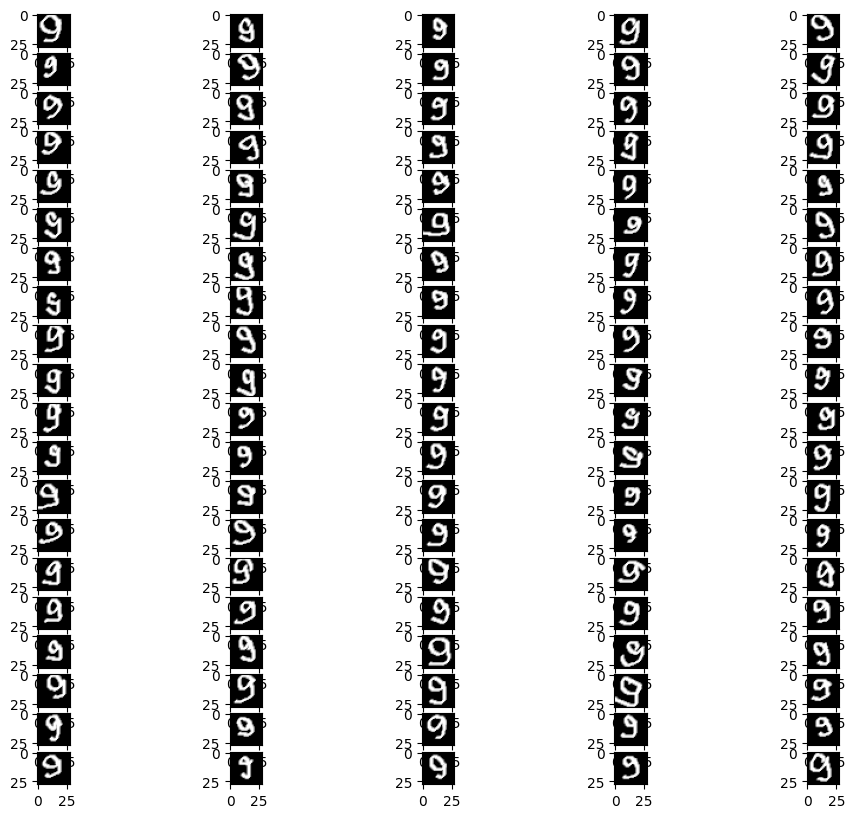

In [63]:
fig, ax = plt.subplots(20, 5, figsize=(12, 10))
for i in range(20):
  for j in range(5):
    number = j*20 + i
    img = loaded_arr[number][1:]
    img = np.reshape(img, (28, 28))
    ax[i][j].imshow(img, cmap="gray")
plt.show()